<h1> Project : DSE-2 : Data Mining - I <br>
Classification Model using Naive Bayes Algorithm </h1>
<h3> Prepared By: Nikhil Kumar Sahu, Dhirendra Kumar Patel<br>Course: Bsc (Hons) Computer Science Sem-4</h3>

## Table of Contents

**1.Dataset Explaination\
2.The problem statement\
3.Introduction to Naive Bayes Classification algorithm\
4.Naive Bayes algorithm Working\
5.Import libraries\
6.Import dataset\
7.Exploratory data analysis\
8.Declare feature vector and target variable\
9.Split data into separate training and test set\
10.Feature engineering\
11.Feature scaling\
12.Model training\
13.Predict the test-set results\
14.Check the accuracy score\
15.Confusion matrix with Heatmap \
16.Classification metrices\
17.Calculate class probabilities\
18.Histogram of predicted probabilities\
19.k-Fold Cross Validation(for cv=10) `is result in performance improved for this model ?` \
20.Results and conclusion**


## 1. Dataset description And Explaination


We have used the **Adult Data Set** for this project. We have downloaded this dataset from the UCI Machine Learning Repository website. The data set can be found at the following url:-


https://archive.ics.uci.edu/ml/datasets/Adult



**Dataset Characteristics `Multivariate`\
Subject Area `Social Science`\
Associated Tasks  `Classification`\
Feature Type  `Categorical, Integer`\
Instances `48842`\
Features `14`**

## 2. The problem statement


In this project, We try to make predictions where the **prediction task is to determine whether a person makes over 50K a year**\
We implement `Naive Bayes Classification with` **Scikit-Learn.**

## 3. Introduction to Naive Bayes Classification algorithm


Naïve Bayes classification is a `straightforward and 'powerful algorithm'` for the classification task. Naïve Bayes classification is based on applying Bayes’ theorem with strong independence assumption between the features.  

Naïve Bayes models are also known as `simple Bayes` or `independent Bayes`. All these names refer to the application of Bayes’ theorem in the classifier’s decision rule. Naïve Bayes classifier applies the Bayes’ theorem in practice. This classifier brings the power of Bayes’ theorem to machine learning.

**Naïve Bayes classification produces good results when we use it for textual data analysis.**

## 4. Naive Bayes algorithm Working


Naïve Bayes Classifier uses the Bayes’ theorem to predict membership probabilities for each class such as the probability that given record or data point belongs to a particular class. The class with the highest probability is considered as the most likely class. This is also known as the **Maximum A Posteriori (MAP)**. 

The **MAP for a hypothesis with 2 events A and B is**

**MAP (A)**

= max (P (A | B))

= max (P (B | A) * P (A))/P (B)

= max (P (B | A) * P (A))

Terminology regarding Bayes’ theorem*

-	P (A | B) is a conditional probability – the likelihood of event A occurring given that B is true.

-	P (A | B) is also known as Posterior probability of A given that event B has already occurred.

-	P (B | A) is also a conditional probability – the likelihood of event B occurring given that A is true.

-	P (A) and P (B) are the probabilities of observing A and B independently of each other. This is also known as the marginal or prior probability.

**Here, P (B) is evidence probability. It is used to normalize the result. It remains the same, So, removing it would not affect the result.**

Naïve Bayes Classifier assumes that all the features are unrelated to each other. Presence or absence of a feature does not influence the presence or absence of any other feature. 


In real world datasets, we test a hypothesis given multiple evidence on features. So, the calculations become quite complicated. To simplify the work, the feature independence approach is used to uncouple multiple evidence and treat each as an independent one.


## 5. Import libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

## 6. Import dataset

In [2]:
data = 'adult.data'
df = pd.read_csv(data, header=None, sep=', ', engine='python')
df

,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14
0,39,State-gov,77516,Bachelors,13,Never-married,Adm-clerical,Not-in-family,White,Male,2174,0,40,United-States,<=50K
1,50,Self-emp-not-inc,83311,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,13,United-States,<=50K
2,38,Private,215646,HS-grad,9,Divorced,Handlers-cleaners,Not-in-family,White,Male,0,0,40,United-States,<=50K
3,53,Private,234721,11th,7,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,0,0,40,United-States,<=50K
4,28,Private,338409,Bachelors,13,Married-civ-spouse,Prof-specialty,Wife,Black,Female,0,0,40,Cuba,<=50K
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
32556,27,Private,257302,Assoc-acdm,12,Married-civ-spouse,Tech-support,Wife,White,Female,0,0,38,United-States,<=50K
32557,40,Private,154374,HS-grad,9,Married-civ-spouse,Machine-op-inspct,Husband,White,Male,0,0,40,United-States,>50K
32558,58,Private,151910,HS-grad,9,Widowed,Adm-clerical,Unmarried,White,Female,0,0,40,United-States,<=50K
32559,22,Private,201490,HS-grad,9,Never-married,Adm-clerical,Own-child,White,Male,0,0,20,United-States,<=50K


## 7. Exploratory data analysis

In [3]:
# view dimensions of dataset

df.shape

(32561, 15)

### View top 5 rows of dataset

In [4]:
# preview the dataset

df.head()

,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14
0,39,State-gov,77516,Bachelors,13,Never-married,Adm-clerical,Not-in-family,White,Male,2174,0,40,United-States,<=50K
1,50,Self-emp-not-inc,83311,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,13,United-States,<=50K
2,38,Private,215646,HS-grad,9,Divorced,Handlers-cleaners,Not-in-family,White,Male,0,0,40,United-States,<=50K
3,53,Private,234721,11th,7,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,0,0,40,United-States,<=50K
4,28,Private,338409,Bachelors,13,Married-civ-spouse,Prof-specialty,Wife,Black,Female,0,0,40,Cuba,<=50K


### Rename column names

We can see that the dataset does not have proper column names. The columns are merely labelled as 0,1,2.... and so on. We should give proper names to the columns. I will do it as follows:-

In [5]:
col_names = ['age', 'workclass', 'fnlwgt', 'education', 'education_num', 'marital_status', 'occupation', 'relationship',
             'race', 'sex', 'capital_gain', 'capital_loss', 'hours_per_week', 'native_country', 'income']

df.columns = col_names

df.head()

,age,workclass,fnlwgt,education,education_num,marital_status,occupation,relationship,race,sex,capital_gain,capital_loss,hours_per_week,native_country,income
0,39,State-gov,77516,Bachelors,13,Never-married,Adm-clerical,Not-in-family,White,Male,2174,0,40,United-States,<=50K
1,50,Self-emp-not-inc,83311,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,13,United-States,<=50K
2,38,Private,215646,HS-grad,9,Divorced,Handlers-cleaners,Not-in-family,White,Male,0,0,40,United-States,<=50K
3,53,Private,234721,11th,7,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,0,0,40,United-States,<=50K
4,28,Private,338409,Bachelors,13,Married-civ-spouse,Prof-specialty,Wife,Black,Female,0,0,40,Cuba,<=50K


### View summary of dataset

In [6]:
# view summary of dataset

df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32561 entries, 0 to 32560
Data columns (total 15 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   age             32561 non-null  int64 
 1   workclass       32561 non-null  object
 2   fnlwgt          32561 non-null  int64 
 3   education       32561 non-null  object
 4   education_num   32561 non-null  int64 
 5   marital_status  32561 non-null  object
 6   occupation      32561 non-null  object
 7   relationship    32561 non-null  object
 8   race            32561 non-null  object
 9   sex             32561 non-null  object
 10  capital_gain    32561 non-null  int64 
 11  capital_loss    32561 non-null  int64 
 12  hours_per_week  32561 non-null  int64 
 13  native_country  32561 non-null  object
 14  income          32561 non-null  object
dtypes: int64(6), object(9)
memory usage: 3.7+ MB


We can see that there are no missing values in the dataset. If ---> will confirm this further.

### Types of variables


In this section, I segregate the dataset into categorical and numerical variables. There are a mixture of categorical and numerical variables in the dataset. Categorical variables have data type object. Numerical variables have data type int64.

### Explore categorical variables

**'O' typically refers to object data type in pandas, which often indicates string data.**

In [7]:
# find categorical variables

categorical = [var for var in df.columns if df[var].dtype=='O']

print('There are {} categorical variables\n'.format(len(categorical)))

print('The categorical variables are :\n\n', categorical)

There are 9 categorical variables

The categorical variables are :

 ['workclass', 'education', 'marital_status', 'occupation', 'relationship', 'race', 'sex', 'native_country', 'income']


In [8]:
# view the categorical variables

df[categorical].head()

,workclass,education,marital_status,occupation,relationship,race,sex,native_country,income
0,State-gov,Bachelors,Never-married,Adm-clerical,Not-in-family,White,Male,United-States,<=50K
1,Self-emp-not-inc,Bachelors,Married-civ-spouse,Exec-managerial,Husband,White,Male,United-States,<=50K
2,Private,HS-grad,Divorced,Handlers-cleaners,Not-in-family,White,Male,United-States,<=50K
3,Private,11th,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,United-States,<=50K
4,Private,Bachelors,Married-civ-spouse,Prof-specialty,Wife,Black,Female,Cuba,<=50K


### Summary of categorical variables


- There are 9 categorical variables. 


- The categorical variables are given by `workclass`, `education`, `marital_status`, `occupation`, `relationship`, `race`, `sex`, `native_country` and `income`.


- `income` is the target variable.


### Missing values in categorical variables

In [9]:
# check missing values in categorical variables

df[categorical].isnull().sum()


workclass         0
education         0
marital_status    0
occupation        0
relationship      0
race              0
sex               0
native_country    0
income            0
dtype: int64

We can see that there are no missing values in the categorical variables .**if---> confirm this further**.

### Identifying missing values 

<a href="https://ibb.co/Mh9mdxx"><img src="https://i.ibb.co/6ZNkQ77/image.png" alt="image" border="0"></a>

### source: https://archive.ics.uci.edu/dataset/2/adult

In [10]:
# check missing values in each column
for col in df.columns:
    print(col)
    print(df[col].unique())
    print("\n")

age
[39 50 38 53 28 37 49 52 31 42 30 23 32 40 34 25 43 54 35 59 56 19 20 45
 22 48 21 24 57 44 41 29 18 47 46 36 79 27 67 33 76 17 55 61 70 64 71 68
 66 51 58 26 60 90 75 65 77 62 63 80 72 74 69 73 81 78 88 82 83 84 85 86
 87]


workclass
['State-gov' 'Self-emp-not-inc' 'Private' 'Federal-gov' 'Local-gov' '?'
 'Self-emp-inc' 'Without-pay' 'Never-worked']


fnlwgt
[ 77516  83311 215646 ...  34066  84661 257302]


education
['Bachelors' 'HS-grad' '11th' 'Masters' '9th' 'Some-college' 'Assoc-acdm'
 'Assoc-voc' '7th-8th' 'Doctorate' 'Prof-school' '5th-6th' '10th'
 '1st-4th' 'Preschool' '12th']


education_num
[13  9  7 14  5 10 12 11  4 16 15  3  6  2  1  8]


marital_status
['Never-married' 'Married-civ-spouse' 'Divorced' 'Married-spouse-absent'
 'Separated' 'Married-AF-spouse' 'Widowed']


occupation
['Adm-clerical' 'Exec-managerial' 'Handlers-cleaners' 'Prof-specialty'
 'Other-service' 'Sales' 'Craft-repair' 'Transport-moving'
 'Farming-fishing' 'Machine-op-inspct' 'Tech-support' '?'
 

**Alternate way to identify missing values** 
### Frequency counts of categorical variables

In [11]:
# check missing values in each column 
for col in df.columns:
    print(df[col].value_counts())
    print("\n")

age
36    898
31    888
34    886
23    877
35    876
     ... 
83      6
88      3
85      3
86      1
87      1
Name: count, Length: 73, dtype: int64


workclass
Private             22696
Self-emp-not-inc     2541
Local-gov            2093
?                    1836
State-gov            1298
Self-emp-inc         1116
Federal-gov           960
Without-pay            14
Never-worked            7
Name: count, dtype: int64


fnlwgt
164190    13
203488    13
123011    13
148995    12
121124    12
          ..
232784     1
325573     1
140176     1
318264     1
257302     1
Name: count, Length: 21648, dtype: int64


education
HS-grad         10501
Some-college     7291
Bachelors        5355
Masters          1723
Assoc-voc        1382
11th             1175
Assoc-acdm       1067
10th              933
7th-8th           646
Prof-school       576
9th               514
12th              433
Doctorate         413
5th-6th           333
1st-4th           168
Preschool          51
Name: count, dtype:

**Variables `workclass`, `occupation` and `native_country` which contain missing values**

### Handle missing values in workclass variable

In [12]:
# replace '?' values in workclass variable with `NaN`

df['workclass'].replace('?', np.NaN, inplace=True)

In [13]:
df['workclass'].unique()

array(['State-gov', 'Self-emp-not-inc', 'Private', 'Federal-gov',
       'Local-gov', nan, 'Self-emp-inc', 'Without-pay', 'Never-worked'],
      dtype=object)

Now, we can see that there are no values encoded as `?` in the `workclass` variable.

I will adopt similar approach with `occupation` and `native_country` column.

### Handle missing values in occupation variable

In [14]:
# replace '?' values in occupation variable with `NaN`

df['occupation'].replace('?', np.NaN, inplace=True)

In [15]:
# check labels in occupation variable

df.occupation.unique()

array(['Adm-clerical', 'Exec-managerial', 'Handlers-cleaners',
       'Prof-specialty', 'Other-service', 'Sales', 'Craft-repair',
       'Transport-moving', 'Farming-fishing', 'Machine-op-inspct',
       'Tech-support', nan, 'Protective-serv', 'Armed-Forces',
       'Priv-house-serv'], dtype=object)

### Handle missing values in native_country variable

In [16]:
# replace '?' values in native_country variable with `NaN`

df['native_country'].replace('?', np.NaN, inplace=True)

In [17]:
# check labels in native_country variable

df.native_country.unique()

array(['United-States', 'Cuba', 'Jamaica', 'India', nan, 'Mexico',
       'South', 'Puerto-Rico', 'Honduras', 'England', 'Canada', 'Germany',
       'Iran', 'Philippines', 'Italy', 'Poland', 'Columbia', 'Cambodia',
       'Thailand', 'Ecuador', 'Laos', 'Taiwan', 'Haiti', 'Portugal',
       'Dominican-Republic', 'El-Salvador', 'France', 'Guatemala',
       'China', 'Japan', 'Yugoslavia', 'Peru',
       'Outlying-US(Guam-USVI-etc)', 'Scotland', 'Trinadad&Tobago',
       'Greece', 'Nicaragua', 'Vietnam', 'Hong', 'Ireland', 'Hungary',
       'Holand-Netherlands'], dtype=object)

### Check missing values in categorical variables again

In [18]:
df[categorical].isnull().sum()

workclass         1836
education            0
marital_status       0
occupation        1843
relationship         0
race                 0
sex                  0
native_country     583
income               0
dtype: int64

### We can see that `workclass`, `occupation` and `native_country` variable contains missing values.

In [19]:
##replace nan values for each column with the most frequent value---->MODE

print("workclass :",df['workclass'].mode()[0],"\n")
df['workclass'].fillna(df['workclass'].mode()[0], inplace=True)

print("occupation :",df['occupation'].mode()[0],"\n")
df['occupation'].fillna(df['occupation'].mode()[0], inplace=True)

print("native_country :",df['native_country'].mode()[0],"\n")
df['native_country'].fillna(df['native_country'].mode()[0], inplace=True)

workclass : Private 

occupation : Prof-specialty 

native_country : United-States 



In [20]:
df[categorical].isnull().sum()

workclass         0
education         0
marital_status    0
occupation        0
relationship      0
race              0
sex               0
native_country    0
income            0
dtype: int64

### Now, The missing values in workclass, occupation and native_country have been handeled by replacing with the mode value 

## Number of labels: cardinality


The number of labels within a categorical variable is known as **cardinality**. A high number of labels within a variable is known as **high cardinality**. High cardinality may pose some serious problems in the machine learning model. 

In [21]:
# check for cardinality in categorical variables

for var in categorical:
    print(var, 'contains', len(df[var].unique()), 'labels')

workclass contains 8 labels
education contains 16 labels
marital_status contains 7 labels
occupation contains 14 labels
relationship contains 6 labels
race contains 5 labels
sex contains 2 labels
native_country contains 41 labels
income contains 2 labels


We can see that `native_country` column contains relatively large number of labels as compared to other columns **will-->check for cardinality after train-test split**

High cardinality in the context of data typically refers to having a large number of distinct values in a particular data field.

1. **Statistical Analysis:** High cardinality can lead to imbalanced datasets, which can skew statistical analysis and machine learning models. For example, if one native country has significantly more data points than others, it may dominate the analysis and lead to biased results.

2. **Model Performance:** In machine learning, high cardinality features can be challenging for models to handle efficiently. Some models may struggle to generalize well if they encounter many unique values in a feature, potentially leading to overfitting.

3. **Data Management:** High cardinality can increase the complexity of data management nsive.

4. **Interpretability:** High cardinality features can make it harder to interpret and explain the results of an analysis. Understanding the impact of a specific country on an outcome becomes more difficult when there are many countries with relatively few observatioopriately.ately.

### Explore Numerical Variables

In [22]:
# find numerical variables

numerical = [var for var in df.columns if df[var].dtype!='O']

print('There are {} numerical variables\n'.format(len(numerical)))

print('The numerical variables are :', numerical)

There are 6 numerical variables

The numerical variables are : ['age', 'fnlwgt', 'education_num', 'capital_gain', 'capital_loss', 'hours_per_week']


In [23]:
# view the numerical variables

df[numerical].head()

,age,fnlwgt,education_num,capital_gain,capital_loss,hours_per_week
0,39,77516,13,2174,0,40
1,50,83311,13,0,0,13
2,38,215646,9,0,0,40
3,53,234721,7,0,0,40
4,28,338409,13,0,0,40


### Summary of numerical variables


- There are 6 numerical variables. 


- These are given by `age`, `fnlwgt`, `education_num`, `capital_gain`, `capital_loss` and `hours_per_week`.


- All of the numerical variables are of discrete data type.

## Exploring problems within numerical variables
### Missing values in numerical variables

In [24]:
# check missing values in numerical variables

df[numerical].isnull().sum()

age               0
fnlwgt            0
education_num     0
capital_gain      0
capital_loss      0
hours_per_week    0
dtype: int64

We can see that all the 6 numerical variables do not contain missing values. 

## 8. Declare feature vector and target variable
**(X=instance,Y=classlabel)**

In [25]:
X = df.drop(['income'], axis=1)  
X.head()

,age,workclass,fnlwgt,education,education_num,marital_status,occupation,relationship,race,sex,capital_gain,capital_loss,hours_per_week,native_country
0,39,State-gov,77516,Bachelors,13,Never-married,Adm-clerical,Not-in-family,White,Male,2174,0,40,United-States
1,50,Self-emp-not-inc,83311,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,13,United-States
2,38,Private,215646,HS-grad,9,Divorced,Handlers-cleaners,Not-in-family,White,Male,0,0,40,United-States
3,53,Private,234721,11th,7,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,0,0,40,United-States
4,28,Private,338409,Bachelors,13,Married-civ-spouse,Prof-specialty,Wife,Black,Female,0,0,40,Cuba


In [26]:
y = df['income']
y.head()

0    <=50K
1    <=50K
2    <=50K
3    <=50K
4    <=50K
Name: income, dtype: object

## 9. Split data into separate training and test set

In [27]:
# split X and y into training and testing sets

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.3, random_state = 0)

### **Holdout Method**
The holdout method involves splitting the dataset into two subsets: 
- One for training the model (70-80%)
- Another for testing (20-30%) its performance.

In [28]:
# check the shape of X_train and X_test
X_train.shape, X_test.shape

((22792, 14), (9769, 14))

In [29]:
y_train.shape, y_test.shape

((22792,), (9769,))

## 10. Feature Engineering


**Feature Engineering** is the process of transforming raw data into useful features that help us to understand our model better and increase its predictive power. I will carry out feature engineering on different types of variables.


First, I will display the categorical and numerical variables again separately.

In [30]:
# check data types in X_train

X_train.dtypes

age                int64
workclass         object
fnlwgt             int64
education         object
education_num      int64
marital_status    object
occupation        object
relationship      object
race              object
sex               object
capital_gain       int64
capital_loss       int64
hours_per_week     int64
native_country    object
dtype: object

In [31]:
# display categorical variables

categorical = [col for col in X_train.columns if X_train[col].dtypes == 'O']

categorical

['workclass',
 'education',
 'marital_status',
 'occupation',
 'relationship',
 'race',
 'sex',
 'native_country']

In [32]:
# display numerical variables

numerical = [col for col in X_train.columns if X_train[col].dtypes != 'O']

numerical

['age',
 'fnlwgt',
 'education_num',
 'capital_gain',
 'capital_loss',
 'hours_per_week']

### Engineering missing values in categorical variables

In [33]:
# print percentage of missing values in the categorical variables in training set

X_train.isnull().mean()

age               0.0
workclass         0.0
fnlwgt            0.0
education         0.0
education_num     0.0
marital_status    0.0
occupation        0.0
relationship      0.0
race              0.0
sex               0.0
capital_gain      0.0
capital_loss      0.0
hours_per_week    0.0
native_country    0.0
dtype: float64

In [34]:
X_test.isnull().mean()

age               0.0
workclass         0.0
fnlwgt            0.0
education         0.0
education_num     0.0
marital_status    0.0
occupation        0.0
relationship      0.0
race              0.0
sex               0.0
capital_gain      0.0
capital_loss      0.0
hours_per_week    0.0
native_country    0.0
dtype: float64

As a final check, I check for any missing values in X_train and X_test.

### Encode categorical variables

It's generally recommended to encode categorical variables after the train-test split. The reason for this is to avoid data leakage, which can occur if information from the test set is used to encode categorical variables.
<table>
<thead>
<tr>
<th><b><strong>Aspect</strong></b></th>
<th><b><strong>Encoding Before Split</strong></b></th>
<th><b><strong>Encoding After Split</strong></b></th>
</tr>
</thead>
<tbody>
<tr>
<td><b><strong>Data Leakage</strong></b></td>
<td><span>High risk of data leakage, as information from the test set may influence the encoding.</span></td>
<td><span>Reduces risk of data leakage by ensuring the encoding is based solely on the training data.</span></td>
</tr>
<tr>
<td><b><strong>Model Generalization</strong></b></td>
<td><span>May lead to overfitting, as the model is exposed to the entire dataset’s information.</span></td>
<td><span>Promotes better model generalization by learning from only the training set’s distribution.</span></td>
</tr>
<tr>
<td><b><strong>Consistency</strong></b></td>
<td><span>Ensures encoding consistency across the entire dataset.</span></td>
<td><span>Requires careful handling to maintain encoding consistency between training and test sets.</span></td>
</tr>
<tr>
<td><b><strong>Practicality</strong></b></td>
<td><span>Simplifies preprocessing by encoding the entire dataset at once.</span></td>
<td><span>More complex but safer approach, involving separate encoding steps for training and test sets.</span></td>
</tr>
</tbody>
</table>

In [35]:
# print categorical variables

categorical

['workclass',
 'education',
 'marital_status',
 'occupation',
 'relationship',
 'race',
 'sex',
 'native_country']

In [36]:
X_train[categorical].head()

,workclass,education,marital_status,occupation,relationship,race,sex,native_country
32098,Private,HS-grad,Married-civ-spouse,Craft-repair,Husband,White,Male,United-States
25206,State-gov,HS-grad,Divorced,Adm-clerical,Unmarried,White,Female,United-States
23491,Private,Some-college,Married-civ-spouse,Sales,Husband,White,Male,United-States
12367,Private,HS-grad,Never-married,Craft-repair,Not-in-family,White,Male,Guatemala
7054,Private,7th-8th,Never-married,Craft-repair,Not-in-family,White,Male,Germany


`!pip install category_encoders`

In [37]:
import category_encoders as ce

In [38]:
# encode remaining variables with one-hot encoding
encoder = ce.OneHotEncoder(cols=['workclass', 'education', 'marital_status', 'occupation', 'relationship', 
                                 'race', 'sex', 'native_country'])

X_train = encoder.fit_transform(X_train)

X_test = encoder.transform(X_test) 
#we don't need to fit_transform here as the ecoder has already learnt the pattern of encoding when it was used for encoding X_train

In [39]:
print(X_train.shape)
X_train.head()

(22792, 105)


,age,workclass_1,workclass_2,workclass_3,workclass_4,workclass_5,workclass_6,workclass_7,workclass_8,fnlwgt,...,native_country_32,native_country_33,native_country_34,native_country_35,native_country_36,native_country_37,native_country_38,native_country_39,native_country_40,native_country_41
32098,45,1,0,0,0,0,0,0,0,170871,...,0,0,0,0,0,0,0,0,0,0
25206,47,0,1,0,0,0,0,0,0,108890,...,0,0,0,0,0,0,0,0,0,0
23491,48,1,0,0,0,0,0,0,0,187505,...,0,0,0,0,0,0,0,0,0,0
12367,29,1,0,0,0,0,0,0,0,145592,...,0,0,0,0,0,0,0,0,0,0
7054,23,1,0,0,0,0,0,0,0,203003,...,0,0,0,0,0,0,0,0,0,0


We can see that from the initial 14 columns, we now have 105 columns.

Similarly, I will take a look at the `X_test` set.

In [40]:
print(X_test.shape)
X_test.head()

(9769, 105)


,age,workclass_1,workclass_2,workclass_3,workclass_4,workclass_5,workclass_6,workclass_7,workclass_8,fnlwgt,...,native_country_32,native_country_33,native_country_34,native_country_35,native_country_36,native_country_37,native_country_38,native_country_39,native_country_40,native_country_41
22278,27,1,0,0,0,0,0,0,0,177119,...,0,0,0,0,0,0,0,0,0,0
8950,27,1,0,0,0,0,0,0,0,216481,...,0,0,0,0,0,0,0,0,0,0
7838,25,1,0,0,0,0,0,0,0,256263,...,0,0,0,0,0,0,0,0,0,0
16505,46,1,0,0,0,0,0,0,0,147640,...,0,0,0,0,0,0,0,0,0,0
19140,45,1,0,0,0,0,0,0,0,172822,...,0,0,0,0,0,0,0,0,0,0


We now have training and testing set ready for model building. Before that, we should map all the feature variables onto the same scale. It is called `feature scaling`. I will do it as follows.

## 11. Feature Scaling : Z-Score Scaling

In [41]:
cols = X_train.columns

In [42]:
from sklearn.preprocessing import StandardScaler

sscaler = StandardScaler()

In [43]:
X_train_scaled = sscaler.fit_transform(X_train)
X_test_scaled = sscaler.transform(X_test)

In [44]:
X_train_scaled = pd.DataFrame(X_train_scaled, columns=cols)
X_train_scaled.head()

,age,workclass_1,workclass_2,workclass_3,workclass_4,workclass_5,workclass_6,workclass_7,workclass_8,fnlwgt,...,native_country_32,native_country_33,native_country_34,native_country_35,native_country_36,native_country_37,native_country_38,native_country_39,native_country_40,native_country_41
0,0.470399,0.570055,-0.202289,-0.290435,-0.174298,-0.185855,-0.263047,-0.021974,-0.009368,-0.174981,...,-0.025662,-0.05051,-0.05051,-0.020951,-0.055504,-0.024792,-0.032467,-0.031783,-0.031083,-0.006624
1,0.617346,-1.754218,4.943430,-0.290435,-0.174298,-0.185855,-0.263047,-0.021974,-0.009368,-0.763517,...,-0.025662,-0.05051,-0.05051,-0.020951,-0.055504,-0.024792,-0.032467,-0.031783,-0.031083,-0.006624
2,0.690820,0.570055,-0.202289,-0.290435,-0.174298,-0.185855,-0.263047,-0.021974,-0.009368,-0.017034,...,-0.025662,-0.05051,-0.05051,-0.020951,-0.055504,-0.024792,-0.032467,-0.031783,-0.031083,-0.006624
3,-0.705178,0.570055,-0.202289,-0.290435,-0.174298,-0.185855,-0.263047,-0.021974,-0.009368,-0.415016,...,-0.025662,-0.05051,-0.05051,-0.020951,-0.055504,-0.024792,-0.032467,-0.031783,-0.031083,-0.006624
4,-1.146019,0.570055,-0.202289,-0.290435,-0.174298,-0.185855,-0.263047,-0.021974,-0.009368,0.130127,...,-0.025662,-0.05051,-0.05051,-0.020951,-0.055504,-0.024792,-0.032467,-0.031783,-0.031083,-0.006624


In [45]:
X_test_scaled = pd.DataFrame(X_test_scaled, columns=cols)
X_test_scaled.head()

,age,workclass_1,workclass_2,workclass_3,workclass_4,workclass_5,workclass_6,workclass_7,workclass_8,fnlwgt,...,native_country_32,native_country_33,native_country_34,native_country_35,native_country_36,native_country_37,native_country_38,native_country_39,native_country_40,native_country_41
0,-0.852125,0.570055,-0.202289,-0.290435,-0.174298,-0.185855,-0.263047,-0.021974,-0.009368,-0.115653,...,-0.025662,-0.05051,-0.05051,-0.020951,-0.055504,-0.024792,-0.032467,-0.031783,-0.031083,-0.006624
1,-0.852125,0.570055,-0.202289,-0.290435,-0.174298,-0.185855,-0.263047,-0.021974,-0.009368,0.258106,...,-0.025662,-0.05051,-0.05051,-0.020951,-0.055504,-0.024792,-0.032467,-0.031783,-0.031083,-0.006624
2,-0.999072,0.570055,-0.202289,-0.290435,-0.174298,-0.185855,-0.263047,-0.021974,-0.009368,0.635854,...,-0.025662,-0.05051,-0.05051,-0.020951,-0.055504,-0.024792,-0.032467,-0.031783,-0.031083,-0.006624
3,0.543873,0.570055,-0.202289,-0.290435,-0.174298,-0.185855,-0.263047,-0.021974,-0.009368,-0.395569,...,-0.025662,-0.05051,-0.05051,-0.020951,-0.055504,-0.024792,-0.032467,-0.031783,-0.031083,-0.006624
4,0.470399,0.570055,-0.202289,-0.290435,-0.174298,-0.185855,-0.263047,-0.021974,-0.009368,-0.156455,...,-0.025662,-0.05051,-0.05051,-0.020951,-0.055504,-0.024792,-0.032467,-0.031783,-0.031083,-0.006624


We now have `X_train` dataset ready to be fed into the Gaussian Naive Bayes classifier. I will do it as follows.

## 12. Model training

In [46]:
from sklearn.naive_bayes import GaussianNB

# instantiate the model
gnb = GaussianNB()

# fit the model
gnb.fit(X_train_scaled, y_train)

GaussianNB()

## 13. Predict the test set results

In [47]:
y_pred = gnb.predict(X_test_scaled)

y_pred

array(['>50K', '>50K', '>50K', ..., '>50K', '>50K', '>50K'], dtype='<U5')

## 14. Check accuracy score

In [48]:
from sklearn.metrics import accuracy_score

print('Model accuracy score: {0:0.4f}'. format(accuracy_score(y_test, y_pred)))

Model accuracy score: 0.4651


Here, **y_test** are the true class labels and **y_pred** are the predicted class labels in the test-set.

### We find the accuracy score is only 46.51%, which appears to be quite low(don't you think so?)

We will also compare the train-set and test-set accuracy to check for overfitting.

In [49]:
y_pred_train = gnb.predict(X_train_scaled)
y_pred_train

array(['>50K', '>50K', '>50K', ..., '<=50K', '>50K', '>50K'], dtype='<U5')

In [50]:
print('Training-set accuracy score: {0:0.4f}'. format(accuracy_score(y_train, y_pred_train)))

Training-set accuracy score: 0.4648


# So, Let's Try a different scaling method
## 11v2. Feature Scaling : Robust Scaling

1. *Standardization (Z-score normalization)*: Scales features to mean of 0 and a standard deviation of 1. <u>Suitable for algorithms that assume normally distributed features.</u>

2. *Normalization (Min-max scaling)*: Scales to a range between 0 and 1. <u>Useful when features have varying ranges and no specific distribution assumptions.</u>

3. *Robust Scaling*: Scales using median and interquartile range (IQR) to handle outliers. <u>Suitable for datasets with extreme values.</u>

In [51]:
cols = X_train.columns

In [52]:
from sklearn.preprocessing import RobustScaler

rscaler = RobustScaler()

X_train_scaled2 = rscaler.fit_transform(X_train)

X_test_scaled2 = rscaler.transform(X_test)

In [53]:
X_train_scaled2 = pd.DataFrame(X_train_scaled2, columns=cols)
X_test_scaled2 = pd.DataFrame(X_test_scaled2, columns=cols)

In [54]:
gnb2=GaussianNB()

# fit the model
gnb2.fit(X_train_scaled2, y_train)

GaussianNB()

In [55]:
y_pred2 = gnb2.predict(X_test_scaled2)
y_pred2

array(['<=50K', '<=50K', '>50K', ..., '>50K', '<=50K', '<=50K'],
      dtype='<U5')

In [56]:
print('Model accuracy score: {0:0.4f}'. format(accuracy_score(y_test, y_pred2)))

Model accuracy score: 0.8007


### We find the accuracy score is 80.07%, which is significantly better than the last result.

### Compare the train-set and test-set accuracy

We will also compare the train-set and test-set accuracy to check for overfitting.

In [57]:
y_pred_train2 = gnb2.predict(X_train_scaled2)

y_pred_train2

array(['>50K', '<=50K', '>50K', ..., '<=50K', '>50K', '<=50K'],
      dtype='<U5')

In [58]:
print('Training-set accuracy score: {0:0.4f}'. format(accuracy_score(y_train, y_pred_train2)))

Training-set accuracy score: 0.8005


### Check for overfitting and underfitting

In [59]:
# print the scores on training and test set
print('Training set score: {:.4f}'.format(gnb2.score(X_train_scaled2, y_train)))
print('Test set score: {:.4f}'.format(gnb2.score(X_test_scaled2, y_test)))

Training set score: 0.8005
Test set score: 0.8007


The training-set accuracy score is 80.05% while the test-set accuracy to be 80.07%. These two values are quite comparable. So, there is no sign of overfitting. 


### Compare model accuracy with null accuracy


So, the model accuracy is 80.07%. But, we cannot say that our model is very good based on the above accuracy. We must compare it with the **null accuracy**. 
**Null accuracy is the accuracy that could be achieved by always predicting the most frequent class**

So, we should first check the class distribution in the test set. 

In [60]:
# check class distribution in test set

y_test.value_counts()

income
<=50K    7407
>50K     2362
Name: count, dtype: int64

We can see that the occurences of most frequent class is 7407. So, we can calculate null accuracy by dividing 7407 by total number of occurences.

#### null_accuracy = TP + FP / TN + FN

In [61]:
# check null accuracy score

null_accuracy = (7407/(7407+2362))

print('Null accuracy score: {0:0.4f}'. format(null_accuracy))

Null accuracy score: 0.7582


We can see that our model accuracy score is 80.07% and null accuracy score is 75.82%.

Based on the above analysis we can conclude that our classification model accuracy is good. Our model is doing great for **predicting the class labels**


But,
#### 1. It does not give the underlying distribution of values
#### 2. It does not tell anything about the type of errors our classifer is making

We have another tool called `Confusion matrix` that comes to our rescue.

## 15. Confusion matrix


A confusion matrix is a tool for summarizing the performance of a classification algorithm. A confusion matrix will give us a clear picture of classification model performance and the types of errors produced by the model. It gives us a summary of correct and incorrect predictions broken down by each category. The summary is represented in a tabular form.


Four types of outcomes are possible while evaluating a classification model performance. These four outcomes are described below:-


**True Positives (TP)** – True Positives occur when we predict an observation belongs to a certain class and the observation actually belongs to that class.


**True Negatives (TN)** – True Negatives occur when we predict an observation does not belong to a certain class and the observation actually does not belong to that class.


**False Positives (FP)** – False Positives occur when we predict an observation belongs to a    certain class but the observation actually does not belong to that class. This type of error is called **Type I error.**



**False Negatives (FN)** – False Negatives occur when we predict an observation does not belong to a certain class but the observation actually belongs to that class. This is a very serious error and it is called **Type II error.**



These four outcomes are summarized in a confusion matrix given below.


In [62]:
# Print the Confusion Matrix and slice it into four pieces

from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred2)

print('Confusion matrix\n\n', cm)

print('\nTrue Positives(TP) = ', cm[0,0])

print('\nTrue Negatives(TN) = ', cm[1,1])

print('\nFalse Positives(FP) = ', cm[0,1])

print('\nFalse Negatives(FN) = ', cm[1,0])

Confusion matrix

 [[5914 1493]
 [ 454 1908]]

True Positives(TP) =  5914

True Negatives(TN) =  1908

False Positives(FP) =  1493

False Negatives(FN) =  454


The confusion matrix shows `5914 + 1908 = 7822 correct predictions` and `1493 + 454 = 1947 incorrect predictions`.


In this case, we have

- `True Positives` (Actual Positive:1 and Predict Positive:1) - 5914


- `True Negatives` (Actual Negative:0 and Predict Negative:0) - 1908


- `False Positives` (Actual Negative:0 but Predict Positive:1) - 1493 `(Type I error)`


- `False Negatives` (Actual Positive:1 but Predict Negative:0) - 454 `(Type II error)`

## Heatmap

<Axes: >

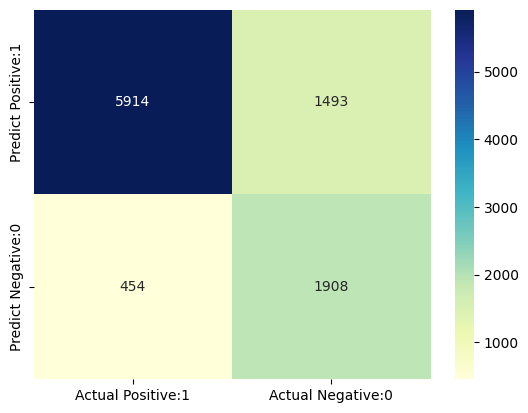

In [63]:
# visualize confusion matrix with seaborn heatmap

cm_matrix = pd.DataFrame(data=cm, columns=['Actual Positive:1', 'Actual Negative:0'], 
                                 index=['Predict Positive:1', 'Predict Negative:0'])

sns.heatmap(cm_matrix, annot=True, fmt='d', cmap='YlGnBu')

## 16. Classification metrices

### Classification Report


**Classification report** is another way to evaluate the classification model performance. It displays the  **precision**, **recall**, **f1** and **support** scores for the model which have been described later.

We can print a classification report as follows:-

In [64]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred2))

              precision    recall  f1-score   support

       <=50K       0.93      0.80      0.86      7407
        >50K       0.56      0.81      0.66      2362

    accuracy                           0.80      9769
   macro avg       0.74      0.80      0.76      9769
weighted avg       0.84      0.80      0.81      9769



### Classification accuracy

In [65]:
TP = cm[0,0]
TN = cm[1,1]
FP = cm[0,1]
FN = cm[1,0]

In [66]:
# print classification accuracy

classification_accuracy = (TP + TN) / float(TP + TN + FP + FN)

print('Classification accuracy : {0:0.4f}'.format(classification_accuracy))

Classification accuracy : 0.8007


### Classification error

In [67]:
# print classification error

classification_error = (FP + FN) / float(TP + TN + FP + FN)

print('Classification error : {0:0.4f}'.format(classification_error))


Classification error : 0.1993


### Precision


**Precision** can be defined as the percentage of correctly predicted positive outcomes out of all the predicted positive outcomes. It can be given as the ratio of true positives (TP) to the sum of true and false positives (TP + FP). 


So, **Precision** identifies the proportion of correctly predicted positive outcome. It is more concerned with the positive class than the negative class.



Mathematically, precision can be defined as the ratio of `TP to (TP + FP)`.



In [68]:
# print precision score

precision = TP / float(TP + FP)

print('Precision : {0:0.4f}'.format(precision))

Precision : 0.7984


### Recall


Recall can be defined as the percentage of correctly predicted positive outcomes out of all the actual positive outcomes.
It can be given as the ratio of true positives (TP) to the sum of true positives and false negatives (TP + FN). **Recall** is also called **Sensitivity**.


**Recall** identifies the proportion of correctly predicted actual positives.


Mathematically, recall can be given as the ratio of `TP to (TP + FN)`.



In [69]:
recall = TP / float(TP + FN)

print('Recall or Sensitivity : {0:0.4f}'.format(recall))

Recall or Sensitivity : 0.9287


### True Positive Rate


**True Positive Rate** is synonymous with **Recall**.


In [70]:
true_positive_rate = TP / float(TP + FN)

print('True Positive Rate : {0:0.4f}'.format(true_positive_rate))

True Positive Rate : 0.9287


### False Positive Rate

In [71]:
false_positive_rate = FP / float(FP + TN)

print('False Positive Rate : {0:0.4f}'.format(false_positive_rate))

False Positive Rate : 0.4390


### Specificity

In [72]:
specificity = TN / (TN + FP)

print('Specificity : {0:0.4f}'.format(specificity))

Specificity : 0.5610


### f1-score


**f1-score** is the weighted harmonic mean of precision and recall. The best possible **f1-score** would be 1.0 and the worst 
would be 0.0.  **f1-score** is the harmonic mean of precision and recall. So, **f1-score** is always lower than accuracy measures as they embed precision and recall into their computation. The weighted average of `f1-score` should be used to 
compare classifier models, not global accuracy.




### Support


**Support** is the actual number of occurrences of the class in our dataset.

## 17. Calculate class probabilities

In [73]:
# print the first 10 predicted probabilities of two classes- 0 and 1

y_pred_prob = gnb2.predict_proba(X_test_scaled2)[0:10]

y_pred_prob

array([[9.99999395e-01, 6.05349483e-07],
       [9.99876583e-01, 1.23417458e-04],
       [1.47622906e-01, 8.52377094e-01],
       [1.64677956e-04, 9.99835322e-01],
       [7.77855561e-09, 9.99999992e-01],
       [9.47389842e-01, 5.26101580e-02],
       [9.99999923e-01, 7.72698188e-08],
       [9.99993105e-01, 6.89534139e-06],
       [9.95115749e-01, 4.88425143e-03],
       [9.99999996e-01, 4.23723155e-09]])

### Observations


- In each row, the numbers sum to 1.


- There are 2 columns which correspond to 2 classes - `<=50K` and `>50K`.

    - Class 0 => <=50K - Class that a person makes less than equal to 50K.    
    
    - Class 1 => >50K  - Class that a person makes more than 50K. 
        
    
- Importance of predicted probabilities

    - We can rank the observations by probability of whether a person makes less than or equal to 50K or more than 50K.


- predict_proba process

    - Predicts the probabilities    
    
    - Choose the class with the highest probability    
    
    
- Classification threshold level

    - There is a classification threshold level of 0.5.    
    
    - Class 0 => <=50K - probability of salary less than or equal to 50K is predicted if probability < 0.5.    
    
    - Class 1 => >50K - probability of salary more than 50K is predicted if probability > 0.5.    
    


In [74]:
# store the probabilities in dataframe

y_pred_prob_df = pd.DataFrame(data=y_pred_prob, columns=['Prob of - <=50K', 'Prob of - >50K'])

y_pred_prob_df

,Prob of - <=50K,Prob of - >50K
0,9.999994e-01,6.053495e-07
1,9.998766e-01,1.234175e-04
2,1.476229e-01,8.523771e-01
3,1.646780e-04,9.998353e-01
4,7.778556e-09,1.000000e+00
5,9.473898e-01,5.261016e-02
6,9.999999e-01,7.726982e-08
7,9.999931e-01,6.895341e-06
8,9.951157e-01,4.884251e-03
9,1.000000e+00,4.237232e-09


In [75]:
# print the first 10 predicted probabilities for class 1 - Probability of >50K

gnb2.predict_proba(X_test_scaled2)[0:10, 1]

array([6.05349483e-07, 1.23417458e-04, 8.52377094e-01, 9.99835322e-01,
       9.99999992e-01, 5.26101580e-02, 7.72698188e-08, 6.89534139e-06,
       4.88425143e-03, 4.23723155e-09])

In [76]:
# store the predicted probabilities for class 1 - Probability of >50K

y_pred2_1 = gnb2.predict_proba(X_test_scaled2)[:, 1]
y_pred2_1

array([6.05349483e-07, 1.23417458e-04, 8.52377094e-01, ...,
       1.00000000e+00, 8.68606812e-03, 1.02328999e-06])

### 18. Histogram of predicted probabilities

Text(0, 0.5, 'Frequency')

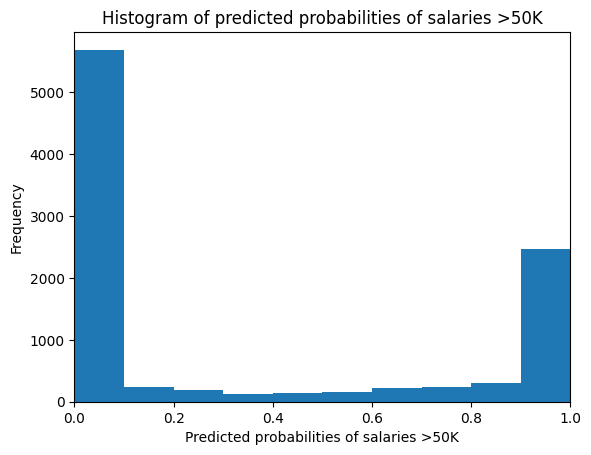

In [77]:
# plot histogram with 10 bins
plt.hist(y_pred2_1, bins = 10)

# set the title of predicted probabilities
plt.title('Histogram of predicted probabilities of salaries >50K')

# set the x-axis limit
plt.xlim(0,1)

# set the title
plt.xlabel('Predicted probabilities of salaries >50K')
plt.ylabel('Frequency')

### Observations


- We can see that the above histogram is highly positive skewed.


- The first column tell us that there are approximately 5700 observations with probability between 0.0 and 0.1 whose salary 
  is <=50K.


- There are relatively small number of observations with probability > 0.5.


- So, these small number of observations predict that the salaries will be >50K.


- Majority of observations predcit that the salaries will be <=50K.

## 19. k-Fold Cross Validation

In [78]:
# Applying 10-Fold Cross Validation

from sklearn.model_selection import cross_val_score

scores = cross_val_score(gnb2, X_train_scaled2, y_train, cv = 10, scoring='accuracy')

print('Cross-validation scores:{}'.format(scores))

Cross-validation scores:[0.80701754 0.7995614  0.80035103 0.80430013 0.79069767 0.79684072
 0.80473892 0.80649408 0.79640193 0.80430013]


We can summarize the cross-validation accuracy by calculating its mean.

In [79]:
# compute Average cross-validation score

print('Average cross-validation score: {:.4f}'.format(scores.mean()))

Average cross-validation score: 0.8011


### Interpretation


- Using the mean cross-validation, we can conclude that we expect the model to be around 80.11% accurate on average.

- If we look at all the 10 scores produced by the 10-fold cross-validation, we can also conclude that there is a relatively small variance in the accuracy between folds, ranging from 80.70% accuracy to 79.06% accuracy. So, we can conclude that the model is independent of the particular folds used for training.

- Our original model accuracy is 0.8007, the mean cross-validation accuracy is 0.8011. So, the 10-fold cross-validation accuracy does not result in a significant performance improvement for this model.

## 20. Results and conclusion


**1.	In this project, I build a Gaussian Naïve Bayes Classifier model to predict whether a person makes over 50K a year. The model yields a very good performance as indicated by the model accuracy which was found to be 0.8007\
2.	The training-set accuracy score is 0.8005 while the test-set accuracy to be 0.8007. These two values are quite comparable. So, there is no sign of overfitting.\
3.	Comparing the model accuracy score which is 0.8007 with null accuracy score which is 0.7582. So, we can conclude that our Gaussian Naïve Bayes classifier model is doing a very good job in predicting the class labels.\
4.	Using the mean cross-validation, we can conclude that we expect the model to be around 80.11% accurate on average.\
5.	If we look at all the 10 scores produced by the 10-fold cross-validation, we can also conclude that there is a relatively small variance in the accuracy between folds, ranging from 80.70% accuracy to 79.06% accuracy. So, we can conclude that the model is independent of the particular folds used for training.\
6.	Our original model accuracy is 0.8007, but the mean cross-validation accuracy is 0.8011. So, the 10-fold cross-validation accuracy does not result in a significant performance improvement for this model**